# MURAM data

## 1. Prerequisites

In [2]:
from glob import glob
from pathlib import Path
import os

import warnings

from tqdm import tqdm

import numpy as np
import astropy.units as u
import pandas as pd
from utils.normalizer import MhdNormalizer, StokesNormalizer

from scipy.interpolate import RegularGridInterpolator, interp1d
from scipy.integrate import cumulative_trapezoid, simpson

import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

plt.rcParams.update({
  'axes.titlesize': 'x-large',  # heading 1
  'axes.labelsize': 'large',   # heading 2
  'xtick.labelsize': 'medium',         # fontsize of the ticks
  'ytick.labelsize': 'medium',         # fontsize of the ticks
  'font.family': 'serif',        # Font family
  'text.usetex': False,          # Do not use LaTeX for text rendering
  'figure.figsize': (10, 8),     # Default figure size
  'savefig.dpi': 300,            # High resolution for saving figures
  'savefig.format': 'png',       # Default format for saving figures
  'legend.fontsize': 'small',  # Font size for legends
  'lines.linewidth': 2,          # Line width for plots
  'lines.markersize': 8,         # Marker size for plots,
  'axes.formatter.useoffset': False,  # Disable offset
  'axes.formatter.use_mathtext': True,  # Use scientific notation
  'axes.formatter.limits': (-3, 4),  # Use scientific notation for values over 10^2
  'axes.labelsize': 'large',     # Font size for axes labels
  'figure.titlesize': 'xx-large', # Font size for suptitles (heading 1)
  'axes.formatter.use_locale': False  # Do not use locale settings
})



ModuleNotFoundError: No module named 'utils'

## 2. Check the data

Let's check if all files are available

In [ ]:
from collections import Counter

file_types = [f"result_{i}" for i in range(8)]
file_types += ["iout", "eos"]

files_in_ms = [Path(file).name for file in glob("/scratchsan/observatorio/juagudeloo/data/muram-simulation/*")]

available_steps = []
missing_report = {}

min_step = 60
max_step = 223
for i in range(min_step, max_step + 1):
    suffix = f".{i:03d}000"
    missing = []
    for ft in file_types:
        filename = f"{ft}{suffix}"
        if filename not in files_in_ms:
            missing.append(ft)
    if missing:
        missing_report[i] = missing
    else:
        available_steps.append(i)

# Pretty per-step log
if missing_report:
    print("Missing files per step:")
    for step in sorted(missing_report):
        miss = missing_report[step]
        print(f"  Step {step:03d}: missing ({len(miss)}/{len(file_types)}): {', '.join(miss)}")
else:
    print(f"All steps from {min_step} to {max_step} have all expected files.")

Missing files per step:
  Step 105: missing (10/10): result_0, result_1, result_2, result_3, result_4, result_5, result_6, result_7, iout, eos
  Step 205: missing (10/10): result_0, result_1, result_2, result_3, result_4, result_5, result_6, result_7, iout, eos


We will create a function that allows automatizing the uploading of the files along with the units conversion.

In [ ]:
ptm = "/scratchsan/observatorio/juagudeloo/data/muram-simulation/"

nx = 480
ny = 480
nz = 256

def load_step(step, ptm: str,
              nx: int, ny: int, nz: int, z_max=None):
    """
    Load a simulation step. `step` can be an int (e.g. 52) or a string
    like '052000' or '052'. Returns a dict with arrays:
    T, P, rho, Vz, Bz and raw fields as needed.
    Optional z_max: keep only z indices 0..z_max-1 (drop top layers).
    """
    from pathlib import Path
    p = Path(ptm)

    # normalize step -> suffix "NNN000"
    if isinstance(step, int):
        suffix = f"{step:03d}000"
    else:
        s = str(step)
        if s.isdigit() and len(s) == 3:
            suffix = f"{int(s):03d}000"
        elif s.isdigit() and len(s) == 6:
            suffix = s
        else:
            # fallback: use as-is
            suffix = s

    def _path(name):
        return p / f"{name}.{suffix}"

    # check required files
    required = ["eos", "result_0", "result_2", "result_6"]
    missing = [r for r in required if not _path(r).exists()]
    if missing:
        raise FileNotFoundError(f"Missing files for step {suffix}: {missing}")

    print("Loading step", suffix)
    # read EOS (2, nx, nz, ny)
    mtpr = np.fromfile(str(_path("eos")), dtype=np.float32)
    mtpr = mtpr.reshape((2, nx, nz, ny), order="C")
    mtpr = mtpr.transpose(0, 1, 3, 2)
    T = mtpr[0, :, :, :]
    P = mtpr[1, :, :, :]

    # helper to read 3D fields (nx, nz, ny)
    def _read3(name):
        arr = np.fromfile(str(_path(name)), dtype=np.float32)
        arr = arr.reshape((nx, nz, ny), order="C")
        return arr.transpose(0, 2, 1)

    rho = _read3("result_0")
    rho_Vz = _read3("result_2")
    Bz = _read3("result_6")

    # derived fields
    Vz = rho_Vz / rho / 1e5  # convert to km/s
    coef = np.sqrt(4.0 * 3.14159265)
    Bz = Bz * coef

    # optionally trim top z layers: keep indices 0..z_max-1
    if z_max is not None:
        if not (0 < z_max <= nz):
            raise ValueError(f"z_max must be in 1..{nz}, got {z_max}")
        T = T[:, :, :z_max]
        P = P[:, :, :z_max]
        rho = rho[:, :, :z_max]
        Vz = Vz[:, :, :z_max]
        Bz = Bz[:, :, :z_max]
        print(f"  trimmed z axis to first {z_max} layers (0..{z_max-1})")

    print("  done.")
    return {
        "T": T*u.K,
        "P": P*u.dyn/u.cm**2,
        "rho": rho*u.g/u.cm**3,
        "Vz": Vz*u.km/u.s,
        "Bz": Bz*u.G,
    }

Let's visualize the content of one step.

In [ ]:
n_step = 112
z_max = 250
sample_muram_data = load_step(n_step, ptm=ptm, nx=nx, ny=ny, nz=nz, z_max = 250)


Loading step 112000


  trimmed z axis to first 250 layers (0..249)
  done.


### 2.1 Geometrical height

#### 2.1.1 Sample step

In [ ]:
def plot_step_surfaces(data, 
                       z_idx=190, 
                       z0 = None, 
                       zero_height=True,
                       height_levels=None, 
                       pixel_size_km = 25,
                       second_plot="profile",
                       quantities=None, 
                       default_cmap="viridis",
                       limit_values=None,
                       save_dir=None,
                       dpi=150,
                       return_figs=False):
    """
    For each quantity in `quantities` create two plots:
      - left: 2D surface at z pixel `z_idx` (axes: x, y)
      - right: profile along z taking the mean over the surface (x,y) for each z

    Returned arrays are expected in shape (nx, ny, nz).
    If `return_figs` is True the function will collect and return the created
    matplotlib.Figure objects (and will NOT save/show them). Otherwise it behaves
    as before (save if save_dir provided, else show).
    """
    if quantities is None:
        quantities = ["T","P","rho","Vx","Vy","Vz","Bx","By","Bz"]

    cmap_map = {
        "T": "hot",
        "P": "summer",
        "rho": "spring",
        "Bx": "PRGn",
        "By": "PRGn",
        "Bz": "PiYG",
        "Vx": "managua",
        "Vy": "managua",
        "Vz": "bwr_r",
    }

    latex_map = {
        "T": r"$T$",
        "P": r"$P$",
        "rho": r"$\rho$",
        "Vx": r"$v_x$",
        "Vy": r"$v_y$",
        "Vz": r"$v_z$",
        "Bx": r"$B_x$",
        "By": r"$B_y$",
        "Bz": r"$B_z$",
    }
    # prepare save directory if requested
    if save_dir is not None:
        save_path = Path(save_dir)
        save_path.mkdir(parents=True, exist_ok=True)
    else:
        save_path = None
        
    available_cm = set(plt.colormaps())
    nz = None

    figs = [] if return_figs else None

    for q in quantities:
        if q not in data:
            print(f"  skipping missing quantity: {q}")
            continue
        q_unit = data[q].unit.to_string("latex")
        arr = data[q].value
        if nz is None:
            nz = arr.shape[2]
        if arr.ndim != 3:
            print(f"  skipping {q}: not a 3D array")
            continue
        if z_idx < 0 or z_idx >= arr.shape[2]:
            print(f"  z_idx {z_idx} out of range for {q} (nz={arr.shape[2]})")
            continue

        cmap_name = cmap_map.get(q, default_cmap)
        if cmap_name not in available_cm:
            print(f"  NOTE: colormap '{cmap_name}' for {q} not available -> using '{default_cmap}'")
            cmap_name = default_cmap
        cmap = plt.get_cmap(cmap_name)

        # surface (x,y) at given z
        surf = arr[:, :, z_idx]
        # profile along z: mean over x,y for each z
        profile = np.nanmean(arr, axis=(0,1))

        fig, axs = plt.subplots(1,2, figsize=(10,4))
        if not limit_values:
            if q in ["Bx", "By", "Bz", "Vz", "Vx", "Vy"]:
                vmin, vmax = np.quantile(surf, [0.01, 0.99])
                if np.abs(vmin) < np.abs(vmax):
                    vmax = -vmin
                else:
                    vmin = -vmax
            else:
                vmin, vmax = None, None
        else:
            vmin, vmax = limit_values[q]
        
        # set q_label before possible modification
        q_label = latex_map.get(q, q)

        if q in ["rho", "P"]:
            profile = np.log10(profile)
            surf = np.log10(surf)
            q_label = q_label + " (log10)"
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            im = axs[0].imshow(surf, origin="lower", cmap=cmap, aspect="auto", vmin = vmin, vmax = vmax)
            axs[0].set_title(rf"{q_label} surface  (z={z_idx})", fontsize=12)
            axs[0].set_axis_off()
            
            scalebar = ScaleBar(pixel_size_km, 'km', length_fraction=0.25, location='lower left', pad=0.5,)
            axs[0].add_artist(scalebar)
            plt.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04, label = f"{q_unit}")

            if second_plot == "profile":
                line_color = cmap(0.6)
                axs[1].plot(height_levels, profile, "-o", ms=3, color=line_color)
                if z0 is not None:
                    axs[1].axvline(z_idx*10-z0*10, color="gray", lw=1, ls="--")
                
                
                # place annotation centered in the profile axes
                y_min, y_max = axs[1].get_ylim()
                y_mid = 0.5 * (y_min + y_max)
                
                if zero_height:
                    axs[1].text(0, y_mid, rf"$T \approx 5780$ K",
                            color='red', fontsize=9, ha='center', va='center',
                            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
                    axs[1].axvline(0, color='red', lw=1.5, ls='-')
                axs[1].set_xlabel("Height (km)")
                axs[1].set_ylabel(f"mean {q_label} (x,y)")
                axs[1].set_title(rf"{q_label} profile along z (mean over x,y)", fontsize=12)
            if second_plot == "histogram":
                axs[1].hist(surf.ravel(), bins=50, color="black", alpha=0.7)
                axs[1].set_xlabel(f"{q_label}")
                axs[1].set_ylabel("Counts")
                axs[1].set_title(rf"{q_label} histogram at z={z_idx}", fontsize=12)
            if second_plot not in ["profile", "histogram"]:
                raise ValueError(f"Unknown second_plot option: {second_plot}")
            
            plt.tight_layout()

            if return_figs:
                figs.append((q, fig))
                # do NOT show or save; caller will handle the figures
            else:
                # save if requested
                if save_path is not None:
                    fname = f"{q}_surface_z{z_idx}.png"
                    outp = save_path / fname
                    fig.savefig(outp, dpi=dpi, bbox_inches='tight')
                    print(f"Saved: {outp}")
                    plt.close(fig)
                else:
                    plt.show()
                    plt.close(fig)

    if return_figs:
        return figs

In [ ]:
# Example call (keeps existing usage)
try:
    T = sample_muram_data.get("T", None)
    mean_T_z = np.nanmean(T, axis=(0,1))
    z0 = int(np.argmin(np.abs(mean_T_z - 5780.0*u.K)))  # reference layer -> height 0
    print(f"The zero layer is at {z0} height pixel")
    
    height_step = 10 #km
    height_levels = np.arange(0,250,1)*height_step - z0*height_step
    plot_step_surfaces(sample_muram_data, 
                       z_idx=190, 
                       z0=z0, 
                       height_levels = height_levels,
                       save_dir = f"./notebooks_images/sample_step/surfaces/{n_step}_step")
except NameError:
    print("sample_muram_data not defined. Load a step first, e.g. `sample_muram_data = load_step(100)`")

The zero layer is at 186 height pixel


Saved: notebooks_images/sample_step/surfaces/112_step/T_surface_z190.png
Saved: notebooks_images/sample_step/surfaces/112_step/P_surface_z190.png
Saved: notebooks_images/sample_step/surfaces/112_step/rho_surface_z190.png
  skipping missing quantity: Vx
  skipping missing quantity: Vy
Saved: notebooks_images/sample_step/surfaces/112_step/Vz_surface_z190.png
  skipping missing quantity: Bx
  skipping missing quantity: By
Saved: notebooks_images/sample_step/surfaces/112_step/Bz_surface_z190.png


Let's see the height at which the optical depth is $\log \tau = 1$. For doing the stratification corresponding to optical depth, we will use the following calculation
\begin{equation}
    \tau(z;T,P) = \int_{z_{\text{max}}}^{z} \kappa(T,P) \log(\rho) dz
\end{equation}
which correspond to the calculation of the optical depth parting from the opacity values multiplied by the volumetric density of the gas. This calculation correspond to the assumption of parallel atmospheres that can be applied on the photosphere thanks to it's behaviour that can be described aproximately through local thermodynamic equilibrium (LTE).

To this purpose we'll do the spline interpolation of the values corresponding to the Rosseland opacity related to specific values of Temperature and pressure

In [ ]:
 # Upload the opacity data
tab_T = np.array([3.32, 3.34, 3.36, 3.38, 3.40, 3.42, 3.44, 3.46, 3.48, 3.50,
                3.52, 3.54, 3.56, 3.58, 3.60, 3.62, 3.64, 3.66, 3.68, 3.70,
                3.73, 3.76, 3.79, 3.82, 3.85, 3.88, 3.91, 3.94, 3.97, 4.00,
                4.05, 4.10, 4.15, 4.20, 4.25, 4.30, 4.35, 4.40, 4.45, 4.50,
                4.55, 4.60, 4.65, 4.70, 4.75, 4.80, 4.85, 4.90, 4.95, 5.00,
                5.05, 5.10, 5.15, 5.20, 5.25, 5.30]) #log(T) in K

tab_p = np.array([-2., -1.5, -1., -0.5, 0., 0.5, 1., 1.5, 2., 2.5,
                3., 3.5, 4., 4.5, 5., 5.5, 6., 6.5, 7., 7.5, 8.]) #log(P) in dyne/cm^2

df_kappa = pd.read_csv('/scratchsan/observatorio/juagudeloo/data/csv/kappa.0.dat', sep='\s+', header=None)
df_kappa.columns = ["Temperature index", "Pressure index", "Opacity value"]
temp_indices = df_kappa["Temperature index" ].unique()
press_indices = df_kappa["Pressure index"].unique()
opacity_values = df_kappa.pivot(index = "Pressure index", columns = "Temperature index", values = "Opacity value").values

Tk = tab_T[temp_indices]
Pk = tab_p[press_indices]
K = opacity_values * u.cm**2 / u.g  # Rosseland mean opacity in cm²/g


<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_174785/3730223826.py:12: SyntaxWarning: invalid escape sequence '\s'
  df_kappa = pd.read_csv('/scratchsan/observatorio/juagudeloo/data/csv/kappa.0.dat', sep='\s+', header=None)


In [ ]:
def limit_values(data, min_val, max_val):
    # find values outside limits (unique to keep list compact)
    below = np.unique(data[data < min_val]).tolist()
    above = np.unique(data[data > max_val]).tolist()
    out = {"below": below, "above": above}
    # clip for subsequent interpolation (keep tiny margin inside bounds)
    clipped = np.clip(data, min_val + 1e-5, max_val - 1e-5)
    return clipped, out

def report_mask_positions(mask, arr, label):
    if not mask.any():
        print(f"\nNo out-of-bounds positions for {label}.\n")
        return
    ix, iy, iz = np.where(mask)
    unique_z, counts = np.unique(iz, return_counts=True)
    print(f"{label} out-of-bounds occurs at z-indices (height indices): {unique_z.tolist()}")
    print(f"Counts per z-index: {dict(zip(unique_z.tolist(), counts.tolist()))}\n")

T_log = np.log10(sample_muram_data["T"].value)
P_log = np.log10(sample_muram_data["P"].value)

# T below / above
mask_T_below = T_log < Tk.min()
mask_T_above = T_log > Tk.max()
report_mask_positions(mask_T_below, T_log, "T (below min Tk)")
report_mask_positions(mask_T_above, T_log, "T (above max Tk)")

# P below / above
mask_P_below = P_log < Pk.min()
mask_P_above = P_log > Pk.max()
report_mask_positions(mask_P_below, P_log, "P (below min Pk)")
report_mask_positions(mask_P_above, P_log, "P (above max Pk)")

# limit values for interpolation
T_log, T_out_of_limits = limit_values(T_log, Tk.min(), Tk.max())
P_log, P_out_of_limits = limit_values(P_log, Pk.min(), Pk.max())

# save combined report of out-of-limits values
out_of_limits_values = {"T": T_out_of_limits, "P": P_out_of_limits}

# prepare interpolator input
PT_log = np.stack((P_log.flatten(), T_log.flatten()), axis=-1)
print("Interpolation bounds:")
print(f"  T: [{Tk.min():.3f}, {Tk.max():.3f}]  (n={len(Tk)})")
print(f"  P: [{Pk.min():.3f}, {Pk.max():.3f}]  (n={len(Pk)})")
print("\nOut-of-limits summary:")

for var in ("T", "P"):
    info = out_of_limits_values.get(var, {"below": [], "above": []})
    below = info["below"]
    above = info["above"]
    print(f"\n{var}:")
    print(f"  below: {len(below)} unique values")
    if below:
        print(f"    min={min(below):.6g}, max={max(below):.6g}, sample={below[:10]}")
    print(f"  above: {len(above)} unique values")
    if above:
        print(f"    min={min(above):.6g}, max={max(above):.6g}, sample={above[:10]}")

# --- new: print the z-indices (heights) where out-of-bounds happen ---
orig_T_log = np.log10(sample_muram_data["T"].value)
orig_P_log = np.log10(sample_muram_data["P"].value)


No out-of-bounds positions for T (below min Tk).


No out-of-bounds positions for T (above max Tk).


No out-of-bounds positions for P (below min Pk).


No out-of-bounds positions for P (above max Pk).



Interpolation bounds:
  T: [3.320, 5.300]  (n=56)
  P: [-2.000, 8.000]  (n=21)

Out-of-limits summary:

T:
  below: 0 unique values
  above: 0 unique values

P:
  below: 0 unique values
  above: 0 unique values


Define the interpolator for obtaining the corresponding opacity values to our simulation distribution of temperature and pressure.

In [ ]:
kappa_interp = RegularGridInterpolator((Pk,Tk), K, method="linear")


Now, let's apply the interpolation and create an array for the $\kappa\log(\rho)$ distribution.

In [ ]:
kappa_rho_interp = kappa_interp(PT_log)
kappa_rho_interp = kappa_rho_interp.reshape(sample_muram_data["T"].shape)*(u.cm**2/u.g)
# κ*ρ: (cm²/g) * (g/cm³) = cm⁻¹ (dimensionless for optical depth integration)
# Extract numeric value for numerical integration
kappa_rho = (kappa_rho_interp * sample_muram_data["rho"]).to(u.cm**-1).value


Finally, let's integrate for each pixel under the parallel-plane atmosphere assumption

In [ ]:
def to_value(quantity, target_unit):
    """
    Extract numeric value from an Astropy Quantity with explicit unit conversion.
    If quantity is already numeric (no .to() method), return as-is.
    
    Parameters
    ----------
    quantity : Quantity or float
        The value to extract.
    target_unit : Quantity
        The unit to convert to (e.g., u.cm).
    
    Returns
    -------
    float
        The numeric value in the target unit.
    """
    if hasattr(quantity, 'to'):
        return quantity.to(target_unit).value
    return quantity


In [ ]:
def compute_logtau(kappa_rho, dz=10*u.km, baseline=1e-5, save_path=None, save_name=None):
    """
    Compute log10(tau) for kappa_rho array of shape (nx, ny, nz).
    Integration is performed from the top (z index = nz-1) downwards.
    
    Parameters
    ----------
    kappa_rho : array-like, shape (nx, ny, nz)
        Opacity times density array (numeric values, already in cm² g / g = cm²).
    dz : Quantity or float, optional
        Grid spacing. Can be a Quantity (e.g., 10*u.km) or numeric value in cm.
        Default is 10 km. Will be converted to cm internally.
    baseline : float, optional
        Minimum tau value before taking log (default: 1e-5).
    save_path : str or Path, optional
        Directory to save the result.
    save_name : str, optional
        Filename for saving. If both provided, array is saved.
    
    Returns
    -------
    logtau : ndarray
        log10(tau) array.
    
    Raises
    ------
    ValueError
        If any tau values are non-positive after clipping.
    """
    kappa_rho = np.asarray(kappa_rho)
    if kappa_rho.ndim != 3:
        raise ValueError("kappa_rho must be a 3D array (nx, ny, nz)")

    # Convert dz to cm if it's a Quantity
    dz_cm = to_value(dz, u.cm)

    # reverse z so axis -1 starts at the top (nz-1)
    kappa_rev = kappa_rho[:, :, ::-1]
    
    # cumulative integral from top to increasing depth (vectorized)
    tau_rev = cumulative_trapezoid(kappa_rev, dx=dz_cm, axis=2, initial=0.0)

    # restore original z-order
    tau = tau_rev[:, :, ::-1]
    tau = np.clip(tau, a_min=1e-30, a_max=None)

    # check for non-positive values and raise if any found
    nonpos_mask = tau <= 0
    if np.any(nonpos_mask):
        cnt = int(np.count_nonzero(nonpos_mask))
        raise ValueError(f"Non-positive tau encountered before log10: {cnt} elements <= 0. "
                         "Investigate kappa_rho or baseline parameter.")

    logtau = np.log10(tau)

    if save_path and save_name:
        outp = Path(save_path) / save_name
        np.save(outp, logtau)

    return logtau


In [ ]:
muram_logtau = compute_logtau(kappa_rho, dz=10*u.km)


In [ ]:
def plot_slices_with_tau_contour(data, logtau, height_levels=None, pixel_size_km = 25,
                                     x_idx=100, quantities=None, default_cmap="viridis",
                                     dz_km=10, figsize=(7,8), save_dir=None, dpi=150,
                                     return_figs=False):
    """
    Same behavior as before, but if return_figs=True the function collects and
    returns the (q, figure) tuples instead of saving/showing them.
    """
    from pathlib import Path

    if quantities is None:
        quantities = ["T","P","rho","Vx","Vy","Vz","Bx","By","Bz"]

    cmap_map = {
        "T": "hot",
        "P": "summer",
        "rho": "spring",
        "Bx": "PRGn",
        "By": "PRGn",
        "Bz": "PiYG",
        "Vx": "managua",
        "Vy": "managua",
        "Vz": "bwr_r",
    }
    latex_map = {
        "T": r"$T$",
        "P": r"$P$",
        "rho": r"$\rho$",
        "Vx": r"$v_x$",
        "Vy": r"$v_y$",
        "Vz": r"$v_z$",
        "Bx": r"$B_x$",
        "By": r"$B_y$",
        "Bz": r"$B_z$",
    }

    # prepare save directory if requested
    if save_dir is not None:
        save_path = Path(save_dir)
        save_path.mkdir(parents=True, exist_ok=True)
    else:
        save_path = None

    # find reference layer z0 from T (mean over x,y)
    if "T" not in data:
        raise ValueError("data must contain 'T' to compute reference z0")
    T = data["T"]
    mean_T_z = np.nanmean(T, axis=(0,1))
    z0 = int(np.argmin(np.abs(mean_T_z - 5780.0*u.K)))  # reference layer -> height 0

    figs = [] if return_figs else None

    for q in quantities:
        if q not in data:
            print(f"  skipping missing quantity: {q}")
            continue
        arr = data[q].value
        if arr.ndim != 3:
            print(f"  skipping {q}: not a 3D array")
            continue
        nx, ny, nz = arr.shape
        if not (0 <= x_idx < nx):
            print(f"  skipping {q}: x_idx {x_idx} out of range (0..{nx-1})")
            continue

        # slice (y, z)
        q_unit = data[q].unit.to_string("latex")
        slice_q = arr[x_idx, :, :]   # shape (ny, nz)
        profile = np.nanmean(arr, axis=(0,1))

        # display transform for rho and P
        display_slice = slice_q.copy()
        display_profile = profile.copy()
        q_label = latex_map.get(q, q)
        if q in ["rho", "P"]:
            # log10 for these two
            # avoid invalid values
            display_slice = np.log10(np.clip(display_slice, 1e-40, None))
            display_profile = np.log10(np.clip(display_profile, 1e-40, None))
            q_label = q_label + " (log10)"

        cmap_name = cmap_map.get(q, default_cmap)
        cmap = plt.get_cmap(cmap_name) if cmap_name in plt.colormaps() else plt.get_cmap(default_cmap)

        # symmetric range for signed quantities
        if q in ["Bx","By","Bz","Vz","Vx","Vy"]:
            vmin, vmax = np.quantile(display_slice, [0.01, 0.99])
            # force symmetric about zero
            maxabs = max(abs(vmin), abs(vmax))
            vmin, vmax = -maxabs, maxabs
        else:
            vmin, vmax = None, None
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fig, ax = plt.subplots(figsize=figsize)
            im = ax.imshow(display_slice.T, origin='lower', aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)

            # remove x ticks for cleaner image, keep y ticks on left to show heights
            ax.set_xticks([])

            # scalebar (matplotlib_scalebar.ScaleBar already imported)
            scalebar = ScaleBar(pixel_size_km, 'km', length_fraction=0.25, location='lower left', pad=0.5)
            ax.add_artist(scalebar)

            # overlay white contour for logtau == 0 (if available)
            if logtau is not None:
                if logtau.shape != arr.shape:
                    print(f"  warning: logtau shape {logtau.shape} does not match {q} shape {arr.shape}; skipping contour")
                else:
                    tau_slice = logtau[x_idx, :, :]
                    ys = np.arange(slice_q.shape[0])
                    zs = np.arange(slice_q.shape[1])
                    CS = ax.contour(ys, zs, tau_slice.T, levels=[0.0], colors='white', linewidths=1.5)
                    if len(CS.allsegs[0]) != 0:
                        segs = CS.allsegs[0]
                        longest = max(segs, key=lambda s: s.shape[0])
                        mid = longest[len(longest) // 2]
                        x_lab, y_lab = mid[0], mid[1]
                        ax.text(x_lab + 1, y_lab + 10, r"$\log \tau = 0$",
                                color="white", fontsize=10, ha="left", va="bottom",
                                bbox=dict(facecolor="black", alpha=0.4, boxstyle="round,pad=0.2"))
                    else:
                        print(f"No contour found at log10(tau)=0 for {q} slice (no crossing).")

            # horizontal marker at z0 and label
            if 0 <= z0 < slice_q.shape[1]:
                ax.axhline(z0, color='yellow', lw=1.5, ls='--')
                ax.text(2, z0 + 2, r'$T\approx 5780$', color='yellow', fontsize=9,
                        bbox=dict(facecolor='black', alpha=0.4, boxstyle='round,pad=0.2'))

            # left-side height ticks: use provided height_levels if available, else compute from dz_km
            n_z = slice_q.shape[1]
            n_ticks = 7
            tick_positions = np.linspace(0, n_z - 1, n_ticks)
            if height_levels is not None and len(height_levels) == n_z:
                tick_labels = [f"{int(height_levels[int(p)])}" for p in tick_positions]
            else:
                tick_labels = [f"{int((p - z0)*dz_km):+d}" for p in tick_positions]
            ax.set_yticks(tick_positions)
            ax.set_yticklabels(tick_labels)
            ax.set_ylabel("Height (km)")

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=f"{q_unit}")
            ax.set_title(f"{q_label} slice at x={x_idx}")
            plt.tight_layout()

            if return_figs:
                figs.append((q, fig))
            else:
                if save_path is not None:
                    fname = f"{q}_slice_x{x_idx}.png"
                    outp = save_path / fname
                    fig.savefig(outp, dpi=dpi, bbox_inches='tight')
                    print(f"Saved: {outp}")
                    plt.close(fig)
                else:
                    plt.show()
                    plt.close(fig)

    if return_figs:
        return figs

In [ ]:
plot_slices_with_tau_contour(sample_muram_data, 
                             muram_logtau, 
                             height_levels = height_levels, 
                             x_idx=120, 
                             figsize = (8,7),
                             save_dir = f"./notebooks_images/sample_step/slices/{n_step}_step",
                             dpi = 200)


Saved: notebooks_images/sample_step/slices/112_step/T_slice_x120.png
Saved: notebooks_images/sample_step/slices/112_step/P_slice_x120.png
Saved: notebooks_images/sample_step/slices/112_step/rho_slice_x120.png
  skipping missing quantity: Vx
  skipping missing quantity: Vy
Saved: notebooks_images/sample_step/slices/112_step/Vz_slice_x120.png
  skipping missing quantity: Bx
  skipping missing quantity: By
Saved: notebooks_images/sample_step/slices/112_step/Bz_slice_x120.png


## 3. Optical Depth Mapping

In [ ]:
#New logtau nodes
new_logtau = np.arange(-2.0,0.1,0.1)
n_logtau = new_logtau.shape[0]
print("The number of optical depths is:", n_logtau)

The number of optical depths is: 21


In [ ]:
#1. Atmospheric quantities iteration

quantities_to_od = ["T", "Vz", "Bz"]
od_muram_data = {}

for q in quantities_to_od:
    print(f"Processing quantity: {q}")
    #2. Pixel iteration
    geom_atm = sample_muram_data[q]
    new_muram_quantity = np.zeros((nx, ny, n_logtau))

    for ix in range(nx):
        for iy in range(ny):
            # Create and apply interpolation function directly
            mapper = interp1d(
                x=muram_logtau[ix, iy, :], 
                y=geom_atm.value[ix, iy, :], 
                kind="linear", 
                bounds_error=False, 
                fill_value="extrapolate"
            )
            new_muram_quantity[ix, iy, :] = mapper(new_logtau)
    od_muram_data[q] = new_muram_quantity*u.Unit(geom_atm.unit)

Processing quantity: T


Processing quantity: Vz
Processing quantity: Bz


In [ ]:
limit_values = {
    "T": (5500, 7000),
    "Vz": (-5, 5),
    "Bz": (-1000, 1000),}

plot_step_surfaces(od_muram_data, 
                   z_idx=20, 
                   zero_height=False,
                   height_levels=new_logtau,
                   pixel_size_km = 25, 
                   second_plot="histogram",
                   quantities=["T","Vz","Bz"],
                   limit_values=limit_values,
                   default_cmap="viridis",
                   save_dir = f"./notebooks_images/sample_step/surfaces_od/{n_step}_step",
                   dpi=150)

Saved: notebooks_images/sample_step/surfaces_od/112_step/T_surface_z20.png
Saved: notebooks_images/sample_step/surfaces_od/112_step/Vz_surface_z20.png
Saved: notebooks_images/sample_step/surfaces_od/112_step/Bz_surface_z20.png


In [ ]:
np.mean(np.abs(sample_muram_data["Bz"]))


<Quantity 79.6497 G>

In [ ]:
max_pos = np.unravel_index(np.argmax(np.abs(od_muram_data["Bz"])), od_muram_data["Bz"].shape)
print(f"Position (ix, iy, iz): {max_pos}")
print(f"Maximum |Bz| value: {np.abs(od_muram_data['Bz'])[max_pos]}")


Position (ix, iy, iz): (374, 360, 20)
Maximum |Bz| value: 1330.5902425670438 G


In [ ]:
np.abs(od_muram_data["T"][max_pos])

<Quantity 5903.02078044 K>

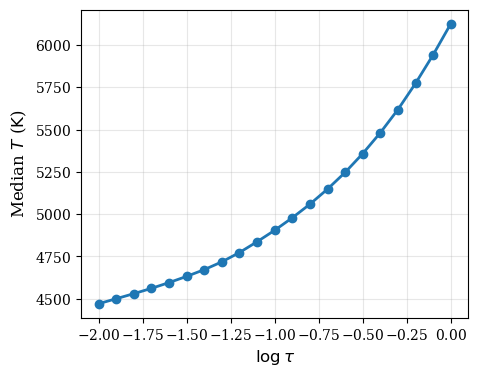

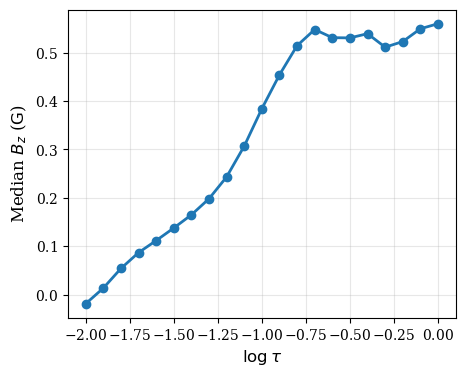

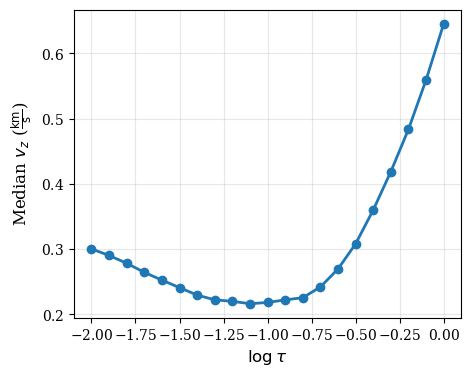

In [ ]:
def plot_medians_vs_logtau(od_muram_data, new_logtau, quantity):
    """
    Plot median values of each quantity in od_muram_data vs new_logtau levels.
    """
    latex_map = {
    "T": r"$T$",
    "P": r"$P$",
    "rho": r"$\\rho$",
    "Bx": r"$B_x$",
    "By": r"$B_y$",
    "Bz": r"$B_z$",
    "Vx": r"$v_x$",
    "Vy": r"$v_y$",
    "Vz": r"$v_z$"
    }   
    
    
    median_values = np.median(od_muram_data[quantity], axis=(0, 1))
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(new_logtau, median_values, marker='o', linewidth=2, markersize=6)
    ax.set_xlabel(r'$\log \tau$')
    ax.set_ylabel(f'Median {latex_map[quantity]} ({median_values.unit.to_string("latex")})')
    ax.grid(True, alpha=0.3)

# Calculate median for each quantity and each height level (axis 2)


for quantity in ['T', 'Bz', 'Vz']:
    plot_medians_vs_logtau(od_muram_data, new_logtau, quantity)

## 4. Data normalization

### 4.1 MHD Normalization

The normalization scheme applies **parameter-specific transformations** independently at **each optical depth level** τ. This ensures equal contribution from all atmospheric heights during training. 



#### 4.1.1 Mathematical Formulation

##### *Temperature Normalization (Standard Scaling)*

For each optical depth level $\tau_k$ where $k \in \{0, 1, ..., 20\}$:

$$
T_{\text{norm}}(x, y, \tau_k) = \frac{T(x, y, \tau_k) - \mu_T(\tau_k)}{\sigma_T(\tau_k) + \epsilon}
$$

**Where:**
- $T(x, y, \tau_k)$: Temperature at spatial position $(x, y)$ and optical depth $\tau_k$ [Kelvin]
- $\mu_T(\tau_k)$: Mean temperature computed across all simulation steps at depth $\tau_k$
- $\sigma_T(\tau_k)$: Standard deviation at depth $\tau_k$
- $\epsilon = 10^{-8}$: Small constant to prevent division by zero

**Physical Interpretation:**
- Temperature stratifies strongly: $T(\tau=-2) \approx 4000$ K (high photosphere) to $T(\tau=0) \approx 7000$ K (deep photosphere)
- Per-$\tau$ normalization ensures the model learns temperature variations at all heights equally

---
#### *Line-of-Sight Velocity Normalization (Centered Scaling)*

For each optical depth level $\tau_k$:

$$
V_{z,\text{norm}}(x, y, \tau_k) = \frac{V_z(x, y, \tau_k)}{\sigma_{V_z}(\tau_k) + \epsilon}
$$

**Where:**
- $V_z(x, y, \tau_k)$: Line-of-sight velocity [km/s]
- $\sigma_{V_z}(\tau_k)$: Standard deviation at depth $\tau_k$
- **No mean subtraction** because velocity is naturally centered around zero (upflows: $V_z < 0$, downflows: $V_z > 0$)

**Physical Interpretation:**
- Convective velocities: $|V_z| \lesssim 5$ km/s
- Preserves the sign information (critical for flow direction)
- Velocity amplitude varies with height due to density stratification

---
#### *Magnetic Field Normalization (Signum-Log + Standard Scaling)*

This is a **two-step transformation** to handle the extreme dynamic range of magnetic fields.

#### Step 3a: Signum-Logarithmic Transform

$$
B_{z,\text{log}}(x, y, \tau_k) = \text{sgn}(B_z) \cdot \log_{10}\left(|B_z(x, y, \tau_k)| + 1\right)
$$

**Where:**
- $\text{sgn}(B_z) = \begin{cases} +1 & \text{if } B_z > 0 \\ -1 & \text{if } B_z < 0 \\ 0 & \text{if } B_z = 0 \end{cases}$
- The $+1$ offset handles zero fields: $\log_{10}(0 + 1) = 0$

**Why Logarithm?**
Magnetic fields span **orders of magnitude**:
- Quiet Sun: $|B_z| \sim 1-10$ G (intergranular network)
- Active regions: $|B_z| \sim 100-1500$ G (magnetic elements)

The log transform compresses this range while preserving polarity:

| Physical $B_z$ [G] | After Signum-Log |
|-------------------|------------------|
| 0                 | 0                |
| +10               | +1.04            |
| +100              | +2.00            |
| +1000             | +3.00            |
| -100              | -2.00            |

##### Step 3b: Standard Scaling (Per-τ)

$$
B_{z,\text{norm}}(x, y, \tau_k) = \frac{B_{z,\text{log}}(x, y, \tau_k) - \mu_{B_z}(\tau_k)}{\sigma_{B_z}(\tau_k) + \epsilon}
$$

**Where:**
- $\mu_{B_z}(\tau_k)$, $\sigma_{B_z}(\tau_k)$: Statistics computed on **log-transformed** values
- Magnetic field strength decreases with height: $|B_z(\tau=-2)| < |B_z(\tau=0)|$

---

#### Inverse Transformation (Denormalization)

During inference, model predictions must be converted back to physical units:

##### *Temperature (Inverse Standard Scaling)*

$$
T(x, y, \tau_k) = T_{\text{norm}}(x, y, \tau_k) \cdot \sigma_T(\tau_k) + \mu_T(\tau_k)
$$

##### *Velocity (Inverse Centered Scaling)*

$$
V_z(x, y, \tau_k) = V_{z,\text{norm}}(x, y, \tau_k) \cdot \sigma_{V_z}(\tau_k)
$$

##### *Magnetic Field (Inverse Signum-Log)*

$$
B_z(x, y, \tau_k) = \text{sgn}(B_{z,\text{norm}}') \cdot \left(10^{|B_{z,\text{norm}}'|} - 1\right)
$$

**Where:**

$$
B_{z,\text{norm}}' = B_{z,\text{norm}}(x, y, \tau_k) \cdot \sigma_{B_z}(\tau_k) + \mu_{B_z}(\tau_k)
$$

---

### Statistics Computation (Welford's Online Algorithm)

To handle memory constraints when processing 164 simulation steps, statistics are computed **incrementally**:

#### Initialization
For each parameter $p \in \{T, V_z, B_z\}$ and each $\tau_k$:

$$
n^{(p)}_k = 0, \quad \mu^{(p)}_k = 0, \quad M_2^{(p)}_k = 0
$$

#### Update Rule
For each new data point $x$:

$$
\begin{align}
n_k &\leftarrow n_k + 1 \\
\delta &= x - \mu_k \\
\mu_k &\leftarrow \mu_k + \frac{\delta}{n_k} \\
\delta' &= x - \mu_k \quad \text{(updated mean)} \\
M_{2,k} &\leftarrow M_{2,k} + \delta \cdot \delta'
\end{align}
$$

#### Finalization

$$
\sigma_k = \sqrt{\frac{M_{2,k}}{n_k}}
$$

**Properties:**
- Mathematically equivalent to batch computation
- Memory-efficient: $\mathcal{O}(1)$ storage per $(\tau_k, \text{parameter})$
- Numerically stable (avoids catastrophic cancellation)

---

### Model Input/Output Format

### Input (Stokes Profiles)
$$
\mathbf{x} \in \mathbb{R}^{2 \times 112}
$$
- 2 channels: Stokes $I$ (intensity), Stokes $V$ (circular polarization)
- 112 wavelength samples: $\lambda \in [6300.5, 6303.5]$ Å with Hinode sampling

#### Output (Normalized Atmospheric Parameters)
$$
\mathbf{y} \in \mathbb{R}^{63}
$$

Concatenated as:
$$
\mathbf{y} = \begin{bmatrix}
T_{\text{norm}}(\tau_0), \ldots, T_{\text{norm}}(\tau_{20}) \\
V_{z,\text{norm}}(\tau_0), \ldots, V_{z,\text{norm}}(\tau_{20}) \\
B_{z,\text{norm}}(\tau_0), \ldots, B_{z,\text{norm}}(\tau_{20})
\end{bmatrix}
$$

**Ordering:** $[T(\tau_0), \ldots, T(\tau_{20}), V_z(\tau_0), \ldots, V_z(\tau_{20}), B_z(\tau_0), \ldots, B_z(\tau_{20})]$

---

### Expected Value Ranges After Normalization

For well-normalized data (across all $\tau_k$):

| Parameter | Expected Range | Mean | Std Dev |
|-----------|---------------|------|---------|
| $T_{\text{norm}}$ | $[-3, +3]$ | $\approx 0$ | $\approx 1$ |
| $V_{z,\text{norm}}$ | $[-4, +4]$ | $\approx 0$ | $\approx 1$ |
| $B_{z,\text{norm}}$ | $[-3, +3]$ | $\approx 0$ | $\approx 1$ |

Values outside $[-5, +5]$ indicate potential outliers or out-of-distribution data.

---

### Advantages of Per-τ Normalization

1. **Equal Loss Contribution**: All atmospheric heights contribute equally to gradients
2. **Physical Stratification**: Respects that $T$, $V_z$, $B_z$ vary systematically with height
3. **Numerical Stability**: Prevents deep photosphere from dominating the loss function
4. **Generalization**: Model learns height-dependent physics rather than absolute scales

In [ ]:
# Load intermediate state
mhd_normalizer = MhdNormalizer()
mhd_normalizer.load(data_path / "normalization_stats/mhd_normalization.json")

normalized_mhd = mhd_normalizer.transform(mhd.od_data)

Per-τ normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/mhd_normalization.json
Optical depth levels: 21


In [ ]:
for key in normalized_mhd:
    print(f"{key} shape: {normalized_mhd[key].shape}, min: {normalized_mhd[key].min():.3f}, max: {normalized_mhd[key].max():.3f}")

T shape: (480, 480, 21), min: -8.218, max: 5.088
Vz shape: (480, 480, 21), min: -3.758, max: 4.840
Bz shape: (480, 480, 21), min: -3.001, max: 3.047


### 4.2 Stokes Normalization

The normalization of Stokes parameters follows a **global standardization approach** computed across all simulation steps. Unlike atmospheric parameters that require per-optical-depth normalization due to stratification, Stokes I and V profiles must preserve their **temporal evolution** and **relative magnitudes** across the simulation.

---

#### Physical Motivation

##### Why Global Normalization?

The MURaM simulation evolves from an initial state with **weak magnetic fields** (early steps: 60–100) to a **magnetoconvective equilibrium** with strong flux concentrations (later steps: 150–223). The Stokes V signal amplitude directly correlates with this evolution:

- **Step 60**: $|V/I_c| \sim 10^{-4}$ (weak internetwork fields)
- **Step 200**: $|V/I_c| \sim 10^{-2}$ (kilogauss flux tubes)

**Per-step normalization would fail** because:
1. Each step would be normalized to the same range (e.g., $[-1, +1]$)
2. The model would lose the ability to distinguish weak vs. strong field regimes
3. Training would be biased toward later steps with larger gradients

**Global normalization preserves**:
- The **physical relationship** between V amplitude and field strength
- The **evolutionary context** of magnetoconvection
- **Balanced gradient contributions** from all simulation phases

---

#### Mathematical Formulation

##### Stokes I Normalization (Z-Score Standardization)

For Stokes I intensity profiles:

$$
I_{\text{norm}}(x, y, \lambda) = \frac{I(x, y, \lambda) - \mu_I}{\sigma_I + \epsilon}
$$

**Where:**
- $I(x, y, \lambda)$: Continuum-normalized intensity at spatial position $(x, y)$ and wavelength $\lambda$ [dimensionless]
- $\mu_I$: Global mean intensity computed across **all simulation steps and wavelengths**
- $\sigma_I$: Global standard deviation across all steps
- $\epsilon = 10^{-8}$: Numerical stability constant

**Physical Interpretation:**
- After continuum normalization, $I \approx 1$ in the continuum and $I \approx 0.2$–$0.8$ in line cores
- $\mu_I \approx 0.82$: Reflects the mean absorption across Fe I 6301.5 Å and 6302.5 Å lines
- $\sigma_I \approx 0.15$: Captures granulation contrast and line depth variations

---

##### Stokes V Normalization (Centered Scaling)

For circular polarization profiles:

$$
V_{\text{norm}}(x, y, \lambda) = \frac{V(x, y, \lambda)}{\sigma_V + \epsilon}
$$

**Where:**
- $V(x, y, \lambda)$: Continuum-normalized circular polarization [dimensionless]
- $\sigma_V$: Global standard deviation across all steps
- **No mean subtraction**: $V$ is naturally centered around zero (positive/negative lobes encode field polarity)

**Physical Interpretation:**
- Stokes V is an **antisymmetric profile** with $\langle V \rangle \approx 0$ (equal positive/negative field regions)
- $\sigma_V \approx 0.004$–$0.006$: Typical V amplitude for mixed polarity regions with $\langle |B_{\text{LOS}}| \rangle \sim 100$–$300$ G
- Preserves the **V/I ratio**, which is proportional to field strength via the Weak Field Approximation (WFA)

---

#### Statistics Computation (Welford's Online Algorithm)

To handle the massive dataset (164 steps × 480×480 pixels × 112 wavelengths ≈ 4.3 billion samples), statistics are computed **incrementally** without loading all data into memory.

##### Initialization

For each Stokes parameter $S \in \{I, V\}$:

$$
n^{(S)} = 0, \quad \mu^{(S)} = 0, \quad M_2^{(S)} = 0
$$

##### Update Rule

For each new sample $x$ (e.g., a single pixel intensity at one wavelength from one step):

$$
\begin{align}
n &\leftarrow n + 1 \\
\delta &= x - \mu \\
\mu &\leftarrow \mu + \frac{\delta}{n} \\
\delta' &= x - \mu \quad \text{(updated mean)} \\
M_2 &\leftarrow M_2 + \delta \cdot \delta'
\end{align}
$$

##### Finalization

After processing all 164 simulation steps:

$$
\sigma = \sqrt{\frac{M_2}{n}}
$$

**Properties:**
- **Memory-efficient**: Only stores 3 scalars per Stokes parameter ($n$, $\mu$, $M_2$)
- **Numerically stable**: Avoids catastrophic cancellation in variance computation
- **Exact**: Mathematically equivalent to batch computation of $\sigma = \sqrt{\mathbb{E}[(X - \mu)^2]}$

---

#### Implementation Details

##### Continuum Normalization (Pre-processing)

Before computing global statistics, each Stokes cube is continuum-normalized:

$$
I_{\text{cont-norm}}(x, y, \lambda) = \frac{I(x, y, \lambda)}{I_c(x, y)}
$$

$$
V_{\text{cont-norm}}(x, y, \lambda) = \frac{V(x, y, \lambda)}{I_c(x, y)}
$$

**Where:**
- $I_c(x, y) = \text{mean}(I(x, y, \lambda_{\text{cont}}))$: Continuum intensity estimated from the first 4 wavelength points
- This removes spatial intensity variations due to limb darkening and granulation

##### Spectral Degradation

To match **Hinode/SOT-SP** observational characteristics, the synthetic Stokes profiles undergo:

1. **Line Spread Function (LSF) Convolution**:
   $$
   I_{\text{conv}}(\lambda) = (I * \text{LSF})(\lambda)
   $$
   Applied with the Hinode SP spline PSF (FWHM ≈ 30 mÅ)

2. **Spectral Resampling**:
   From 300 points (10 mÅ sampling) → 112 points (21.5 mÅ sampling)
   $$
   \lambda_{\text{Hinode}} = \lambda_0 + (i - i_0) \cdot \Delta\lambda, \quad i = 1, \ldots, 112
   $$
   Where $\lambda_0 = 6302.0$ Å, $\Delta\lambda = 0.0215$ Å, $i_0 = 57$

These transformations are applied **before** computing normalization statistics to ensure the model trains on realistic data.

---

#### Model Input Format

##### Input (Normalized Stokes Profiles)

$$
\mathbf{x} \in \mathbb{R}^{2 \times 112}
$$

Constructed as:

$$
\mathbf{x} = \begin{bmatrix}
I_{\text{norm}}(\lambda_1), & I_{\text{norm}}(\lambda_2), & \ldots, & I_{\text{norm}}(\lambda_{112}) \\
V_{\text{norm}}(\lambda_1), & V_{\text{norm}}(\lambda_2), & \ldots, & V_{\text{norm}}(\lambda_{112})
\end{bmatrix}
$$

- **Channel 0**: Normalized intensity profile (absorption line shape)
- **Channel 1**: Normalized circular polarization (magnetic field signature)
- **Wavelength range**: $\lambda \in [6300.79, 6303.19]$ Å (Hinode/SP window)

---

#### Expected Value Ranges After Normalization

For well-normalized data across all simulation steps:

| Parameter | Expected Range | Mean | Std Dev | Physical Range (Pre-Norm) |
|-----------|---------------|------|---------|---------------------------|
| $I_{\text{norm}}$ | $[-3, +3]$ | $\approx 0$ | $\approx 1$ | $I \in [0.2, 1.0]$ (continuum-normalized) |
| $V_{\text{norm}}$ | $[-5, +5]$ | $\approx 0$ | $\approx 1$ | $V/I_c \in [-0.02, +0.02]$ |

**Interpretation:**
- **$I_{\text{norm}} \in [-3, +3]$**: Covers from deep line cores ($I \approx 0.2$) to continuum ($I \approx 1.0$)
- **$V_{\text{norm}} \in [-5, +5]$**: Captures weak fields ($|V| \sim 10^{-4}$) to kilogauss elements ($|V| \sim 10^{-2}$)
- Values outside $[-6, +6]$ indicate potential outliers or unrealistic Stokes profiles

---

#### Relationship to Physics-Informed Loss

The normalized Stokes V profiles directly constrain the model's predictions via the **Weak Field Approximation (WFA)**:

$$
V(\lambda) \approx -\frac{e}{4\pi m_e c} \lambda_0^2 g B_{\text{LOS}} \frac{dI}{d\lambda}
$$

After normalization, the WFA-derived magnetic field becomes:

$$
B_{\text{LOS}}^{\text{WFA}} = -\frac{V_{\text{norm}} \cdot \sigma_V}{\mathcal{C} \lambda_0^2 g \, dI_{\text{norm}}/d\lambda}
$$

Where $\mathcal{C} = e / (4\pi m_e c) = 4.67 \times 10^{-13}$ G$^{-1}$Å$^{-1}$ is the Zeeman splitting constant.

**Key point**: By preserving the **V/I ratio** through global normalization, the physics-informed loss correctly penalizes predictions inconsistent with Zeeman splitting.

---

#### Inverse Transformation (Denormalization)

During inference, normalized Stokes predictions must be converted back to physical units:

##### Stokes I (Inverse Z-Score)

$$
I(x, y, \lambda) = I_{\text{norm}}(x, y, \lambda) \cdot \sigma_I + \mu_I
$$

##### Stokes V (Inverse Centered Scaling)

$$
V(x, y, \lambda) = V_{\text{norm}}(x, y, \lambda) \cdot \sigma_V
$$

**Note**: If the model is used for **Stokes synthesis** (not implemented here), the output would be in continuum-normalized units ($I/I_c$, $V/I_c$). The absolute continuum level $I_c$ can be estimated from the mean of the first few wavelength points in $I(\lambda)$.

---

#### Advantages of Global Stokes Normalization

1. **Temporal Consistency**: All simulation phases (weak → strong fields) contribute equally to defining "typical" Stokes signals
2. **Physical Interpretability**: $\sigma_V$ represents the RMS polarization across the full magnetoconvective cycle
3. **Gradient Balance**: Prevents early steps (weak V) from being ignored due to small gradients
4. **WFA Compatibility**: Preserves the $V \propto B_{\text{LOS}} \cdot dI/d\lambda$ relationship needed for physics regularization
5. **Generalization**: Model learns to map Stokes amplitudes → field strengths across the full dynamic range ($B_{\text{LOS}} \in [0, 1500]$ G)

---

#### Verification Procedure

After computing normalization statistics, verify correctness with:

```python
# Load statistics
with open("stokes_normalization_stats.json", 'r') as f:
    stats = json.load(f)

# Apply normalization to a test step
stokes_norm = {
    'I': (stokes['I'] - stats['I']['mean']) / stats['I']['std'],
    'V': stokes['V'] / stats['V']['std']
}

# Check: Should be ~N(0,1)
print(f"I_norm: mean={stokes_norm['I'].mean():.4f}, std={stokes_norm['I'].std():.4f}")
print(f"V_norm: mean={stokes_norm['V'].mean():.4f}, std={stokes_norm['V'].std():.4f}")

# Check: Original V/I ratio preserved
ratio_original = stokes['V'].std() / stokes['I'].std()
ratio_normalized = stokes_norm['V'].std() / stokes_norm['I'].std()
print(f"V/I ratio: original={ratio_original:.4e}, normalized={ratio_normalized:.4e}")
# Should be approximately equal
```

**Expected output:**
```
I_norm: mean=0.0000, std=1.0000
V_norm: mean=0.0000, std=1.0000
V/I ratio: original=0.0029, normalized=0.0029
```

This confirms:
- ✓ Both parameters are properly standardized
- ✓ The physical V/I ratio is preserved
- ✓ Model will receive balanced inputs for learning

In [ ]:
# Load intermediate state
stokes_normalizer = StokesNormalizer()
stokes_normalizer.load(data_path / "normalization_stats/stokes_normalization.json")

normalized_stokes = stokes_normalizer.transform(stokes.data)


Stokes normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/stokes_normalization.json


In [ ]:
for key in normalized_stokes:
    print(f"{key} shape: {normalized_stokes[key].shape}, quantile 1: {np.quantile(normalized_stokes[key], 0.01):.3f}, quantile 99: {np.quantile(normalized_stokes[key], 0.99):.3f} max: {np.max(normalized_stokes[key]):.3f} min: {np.min(normalized_stokes[key]):.3f}")

I shape: (480, 480, 112), quantile 1: -2.904, quantile 99: 1.792 max: 2.230 min: -3.393
V shape: (480, 480, 112), quantile 1: -1.550, quantile 99: 1.576 max: 50.944 min: -53.856
